In [96]:
#import the libraries
import numpy as np
import matplotlib.pyplot as mtp
import pandas as pd

In [97]:
#import dataset
dataset = pd.read_csv('Loan.csv')

#putting 0 for missing values
dataset = dataset.fillna(0)

print(dataset.isna().sum())

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


In [98]:
#viewing dataset
dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,0.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [99]:
#converting to boolean
dataset.loc[dataset['Loan_Status'] == 'Y', 'LOAN_YN'] = 1
dataset.loc[dataset['Loan_Status'] == 'N', 'LOAN_YN'] = 0
dataset.loc[dataset['Education'] == 'Graduate', 'ED'] = 1
dataset.loc[dataset['Education'] == 'Not Graduate', 'ED'] = 0
dataset.loc[dataset['Self_Employed'] == 'No', 'JOB'] = 1
dataset.loc[dataset['Self_Employed'] == 'Yes', 'JOB'] = 0

dataset = dataset.fillna(0)

dataset.head()


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,LOAN_YN,ED,JOB
0,LP001002,Male,No,0,Graduate,No,5849,0.0,0.0,360.0,1.0,Urban,Y,1.0,1.0,1.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N,0.0,1.0,1.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y,1.0,1.0,0.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y,1.0,0.0,1.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y,1.0,1.0,1.0


In [100]:
#extracting independent and dependent variables
x = dataset.iloc[:,[14,15]].values
y = dataset.iloc[:,13].values

In [101]:
#splitting into training and test
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.25, random_state = 0)

In [102]:
#feature scaling
from sklearn.preprocessing import StandardScaler
st_x = StandardScaler()
x_train = st_x.fit_transform(x_train)
x_test = st_x.transform(x_test)
y_test

array([1., 0., 1., 0., 1., 0., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 0.,
       1., 1., 0., 0., 1., 1., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1.,
       1., 0., 1., 1., 1., 1., 1., 0., 1., 1., 1., 1., 1., 1., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 1., 1., 1., 0., 1., 0., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 1., 1., 1., 0., 0., 1., 0., 1., 0., 0., 1., 0.,
       1., 1., 1., 1., 1., 1., 0., 0., 0., 1., 0., 1., 1., 1., 1., 1., 1.,
       1., 0., 1., 1., 1., 1., 1., 0., 1., 0., 0., 1., 0., 1., 1., 1., 1.,
       1., 1., 0., 1., 1., 0., 0., 1., 1., 0., 1., 1., 1., 0., 0., 1., 1.,
       1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 1., 0., 0., 1., 1., 1.,
       0.])

In [103]:
#KNN
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 5, metric = 'euclidean')
classifier.fit(x_train, y_train)

KNeighborsClassifier(metric='euclidean')

In [104]:
#predicting
y_pred = classifier.predict(x_test)

In [105]:
#confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

In [111]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)


0.6688311688311688

In [112]:
from sklearn.metrics import precision_recall_fscore_support
precision_recall_fscore_support(y_test, y_pred)

(array([0.21428571, 0.71428571]),
 array([0.06976744, 0.9009009 ]),
 array([0.10526316, 0.79681275]),
 array([ 43, 111], dtype=int64))

In [113]:
from sklearn.metrics import precision_score
precision_score(y_test, y_pred)


0.7142857142857143

In [114]:
from sklearn.metrics import recall_score
recall_score(y_test, y_pred)


0.9009009009009009

In [115]:
from sklearn.metrics import f1_score
f1_score(y_test, y_pred)

0.796812749003984

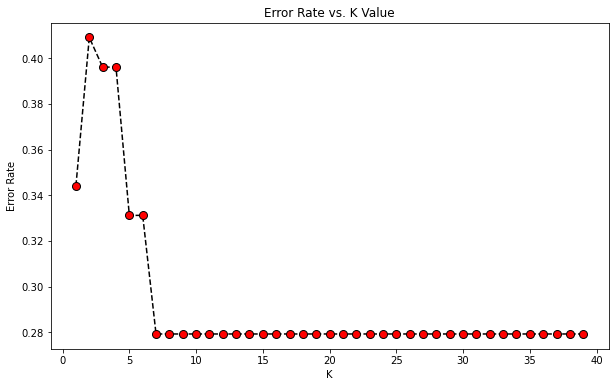

Minimum error:- 0.27922077922077926 at K = 7


In [118]:
from matplotlib import pyplot as plt
error_rate = []
for i in range(1,40):
 classifier = KNeighborsClassifier(n_neighbors=i)
 classifier.fit(x_train,y_train)
 pred = classifier.predict(x_test)
 error_rate.append(1-accuracy_score(y_test, pred))

plt.figure(figsize=(10,6))
plt.plot(range(1,40),error_rate,color='black', linestyle='dashed', 
         marker='o',markerfacecolor='red', markersize=8)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()
print("Minimum error:-",min(error_rate),"at K =",error_rate.index(min(error_rate))+1)

In [119]:
classifier = KNeighborsClassifier(n_neighbors=7, metric='euclidean')
classifier.fit(x_train, y_train)

KNeighborsClassifier(metric='euclidean', n_neighbors=7)

In [121]:
y_pred = classifier.predict(x_test)
accuracy_score(y_test, y_pred)


0.7207792207792207